# Used car's price prediction

# Шаг 3: построение baseline-модели

## Описание задачи

Многие знают про маркетплейсы где продаются б/у вещи, на которых есть возможность недорого купить качественную и полезную вещь. Но всегда волнует вопрос - кто и как устанавливает цену, и какие его характеристики больше всего влияют на итоговую стоимость продажи?!  
Вопрос становиться особо актуальным, если речь идет про дорогие товары, например про автомобили!

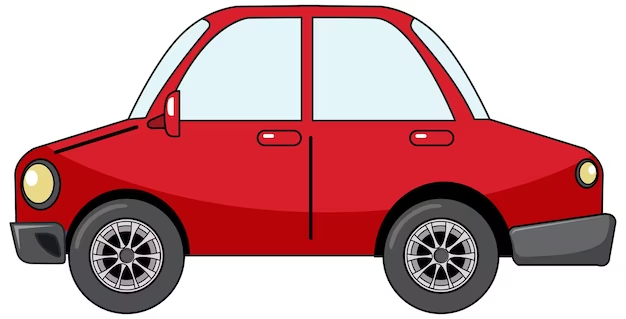

## Импорт библиотек, константы и загрузка данных

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
RANDOM_STATE = 42

Будем работать с данными `train.csv`.

Когда финальная модель будет готова, с помощью нее предскажем цены на машины из файла `test.csv` (там ответов нет).

In [3]:
TEST = "https://www.dropbox.com/s/asf4b1z1yme5o7u/cars_test.csv"
TRAIN = "https://www.dropbox.com/s/qk4b79i7c078sxm/cars_train.csv?dl=1"

In [4]:
data = pd.read_csv(TRAIN)

In [5]:
data.shape

(396212, 15)

Выделим целевую переменную `sellingprice` в отдельную переменную `y`, а `X` - матрица объект-признак.

In [6]:
X = data.drop('sellingprice', axis=1)
y = data['sellingprice']

**Описание данных**

**_Признаки_**
- `year` - год производства
- `make` - производитель
- `model` - модель
- `trim` - модификация
- `body` - тип кузова
- `transmission` - тип КПП
- `vin` - идентификатор (вин)
- `state` - штат регистрации
- `condition` - состояние по шкале (1-5)
- `odometer` - пробег в милях
- `color` - цвет кузова
- `interior` - цвет интерьера
- `seller` - продавец
- `saledate` - дата продажи

**_Целевой признак_**
- `sellingprice` - стоимость продажи

In [ ]:
X.head()

,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,saledate
0,2013,Dodge,Dart,Limited,Sedan,automatic,1c3cdfca5dd293552,mo,4.6,13957.0,gray,black,chrysler capital,Wed Jan 21 2015 02:30:00 GMT-0800 (PST)
1,2014,Honda,Civic,LX,Sedan,automatic,19xfb2f56ee228781,ca,5.0,2401.0,gray,black,"ahfc/honda lease trust/hvt, inc.",Thu Feb 26 2015 04:00:00 GMT-0800 (PST)
2,2012,Chevrolet,Traverse,LT,suv,automatic,1gnkrged3cj244704,wi,2.4,70046.0,white,black,capital one auto finance,Wed Jun 17 2015 03:00:00 GMT-0700 (PDT)
3,2014,Nissan,Versa Note,1.6 SV,Hatchback,automatic,3n1ce2cp9el407766,fl,2.6,23415.0,gray,black,florida auto financial group,Tue Feb 17 2015 01:30:00 GMT-0800 (PST)
4,2014,Nissan,Versa,1.6 SV,sedan,automatic,3n1cn7ap4el813308,il,3.4,17040.0,blue,black,nissan motor acceptance corporation,Thu Jun 04 2015 03:00:00 GMT-0700 (PDT)


Посмотрим на типы колонок и число пропущенных значений в них.

In [ ]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 396212 entries, 0 to 396211
Data columns (total 14 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   year          396212 non-null  int64  
 1   make          388993 non-null  object 
 2   model         388922 non-null  object 
 3   trim          388727 non-null  object 
 4   body          386883 non-null  object 
 5   transmission  350025 non-null  object 
 6   vin           396212 non-null  object 
 7   state         396212 non-null  object 
 8   condition     387759 non-null  float64
 9   odometer      396151 non-null  float64
 10  color         395679 non-null  object 
 11  interior      395679 non-null  object 
 12  seller        396212 non-null  object 
 13  saledate      396212 non-null  object 
dtypes: float64(2), int64(1), object(11)
memory usage: 42.3+ MB


Посмотрим на числовые признаки

In [ ]:
X.describe()

,year,condition,odometer
count,396212.000000,387759.000000,396151.000000
mean,2010.041442,3.425687,68336.479029
std,3.977384,0.949871,53559.280598
min,1982.000000,1.000000,1.000000
25%,2007.000000,2.700000,28259.000000
50%,2012.000000,3.600000,52113.000000
75%,2013.000000,4.200000,99300.000000
max,2015.000000,5.000000,999999.000000


Посмотрим на категориальные признаки

In [22]:
X.describe(include='object')

C:\Users\e.karandashova.INSIDE\AppData\Local\Temp\ipykernel_3516\87029547.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  X.describe(include='object')


,model,trim,body,transmission,state,color,interior,seller,date
count,388922,388727,386883,350025,396212,395679,395679,396212,396212
unique,949,1899,83,2,38,20,17,12530,9
top,Altima,Base,Sedan,automatic,fl,black,black,nissan-infiniti lt,Feb2015
freq,13969,39538,141921,337646,59164,78576,173230,14323,114662


Признак `vin` это уникальный идентификатор машины, поэтому удалим его.

In [7]:
X.drop('vin', axis=1, inplace=True)

# Разведочный анализ данных

## Заполнение пропусков

Заполним пропуски в числовых столбцах средним значением, а в категориальных - пустой категорией

In [8]:
for c in X.columns:
    if X[c].dtype == 'object':
          X[c].fillna("", inplace=True)

C:\Users\e.karandashova.INSIDE\AppData\Local\Temp\ipykernel_5404\1260527268.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X[c].fillna("", inplace=True)


In [9]:
for c in X.columns:
    if X[c].dtype != 'object':
          mean = np.mean(X[c])
          X[c].fillna(mean, inplace=True)

C:\Users\e.karandashova.INSIDE\AppData\Local\Temp\ipykernel_5404\4102773569.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X[c].fillna(mean, inplace=True)


## Обработка категориальных признаков - 1

Посмотрим на количество значений в каждой категории

In [13]:
for c in X.columns:
    if X[c].dtype == 'object':
          print(c, len(X[c].unique()))

В saledate очень много различных значений. Посмотрим почему.

In [14]:
X[['year','saledate']]

KeyError: "['saledate'] not in index"

Обработаем saledate:
* сделаем признак `car_age` - возраст машины в годах
* сделаем признак date - месяц+год продажи машины (категориальный)

Исходный признак `saledate` удалим

In [11]:
X['car_age'] = X['saledate'].apply(lambda x: int(x.split(" ")[3])) - X['year']
X['date'] = X['saledate'].apply(lambda x: x.split(" ")[1]+x.split(" ")[3])

X.drop('saledate', axis=1, inplace=True)

In [15]:
import seaborn as sb

X['target'] = y

cols = X.columns[X.dtypes != 'object']

corr = X[cols].corr()
sb.heatmap(corr, cmap="Blues", annot=True)

X.drop('target', axis=1, inplace=True)

ValueError: could not convert string to float: 'Dodge'

Все числовые признаки важны, запомним это

Посмотрим на аналог корреляции категориальных признаков

In [16]:
!pip install association-metrics

In [17]:
import association_metrics as am

XC = X.apply(
        lambda x: x.astype("category") if x.dtype == "object" else x)

cramersv = am.CramersV(XC)

cramersv.fit()

KeyError: 'No categorical variables found'

Признаки make и model сильно связаны, поэтому уберем make как менее информативный

In [18]:
X.drop('make', axis=1, inplace=True)

Как посмотреть влияние категориального признака на целевую переменную? Здесь лучше всего поможет scatterplot

<Axes: xlabel='None', ylabel='sellingprice'>

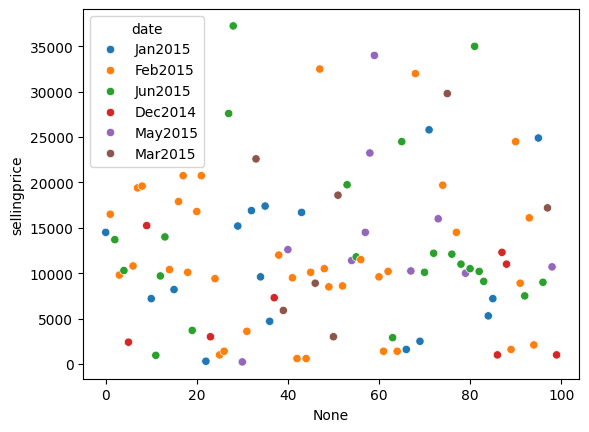

In [19]:
import seaborn as sns

sns.scatterplot(data=X.iloc[:100], x=X.iloc[:100].index, y=y[:100], hue='date')

<Axes: ylabel='sellingprice'>

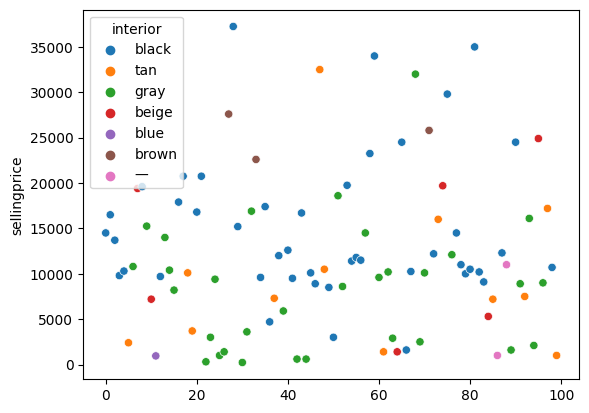

In [ ]:
sns.scatterplot(data=X.iloc[:100], x=X.iloc[:100].index, y=y[:100], hue='interior')

<Axes: ylabel='sellingprice'>

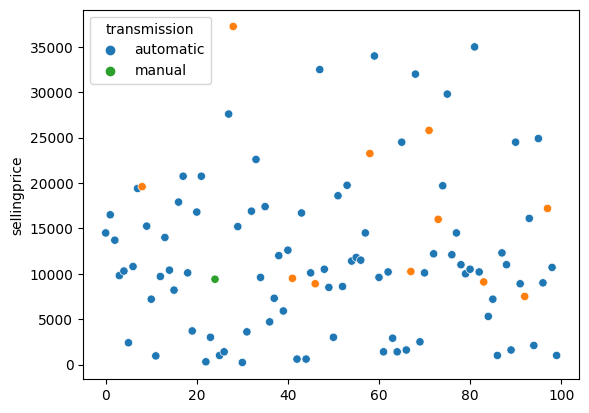

In [ ]:
sns.scatterplot(data=X.iloc[:100], x=X.iloc[:100].index, y=y[:100], hue='transmission')

Посмотрим на распределение целевой переменной

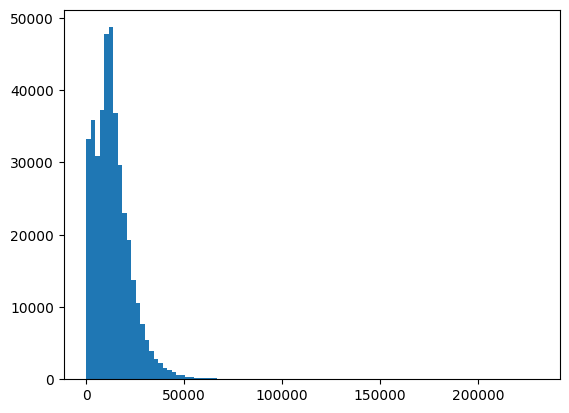

In [ ]:
plt.hist(y, bins=100);

Пока мы не будем ничего делать с этим распределением, но известно, что с распределениями, отличными от нормального, большинству моделей сложно работать.

Поэтому при улучшении качества базового решения мы преобразуем это распределение.

## Поиск аномальных значений

In [20]:
cat_cols = X.columns[X.dtypes == 'object']
num_cols = X.columns[X.dtypes != 'object']

year


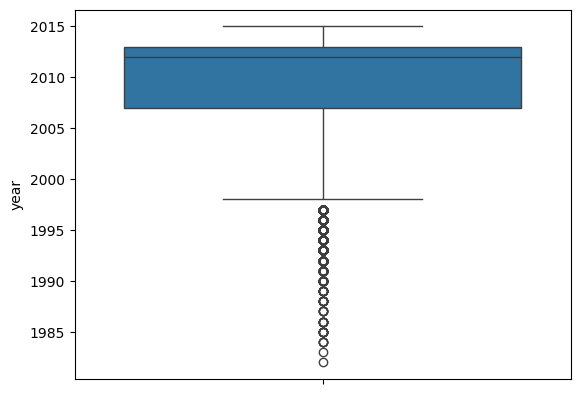

model


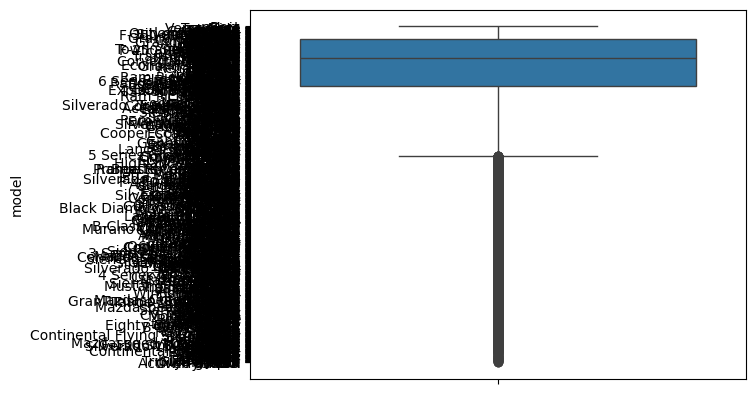

trim


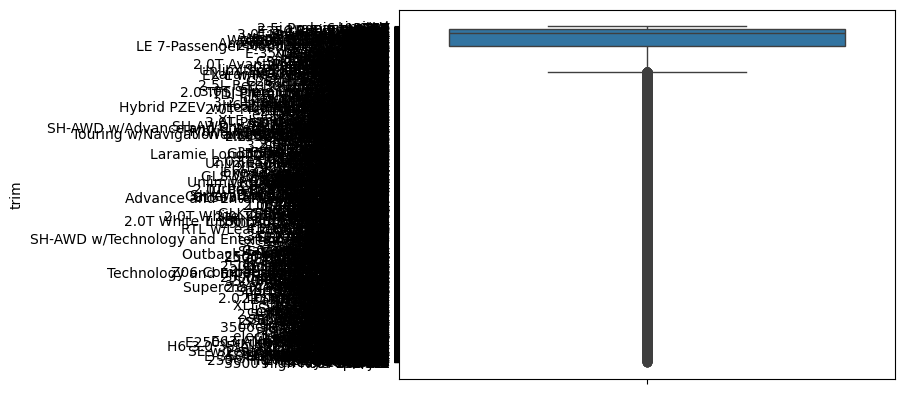

body


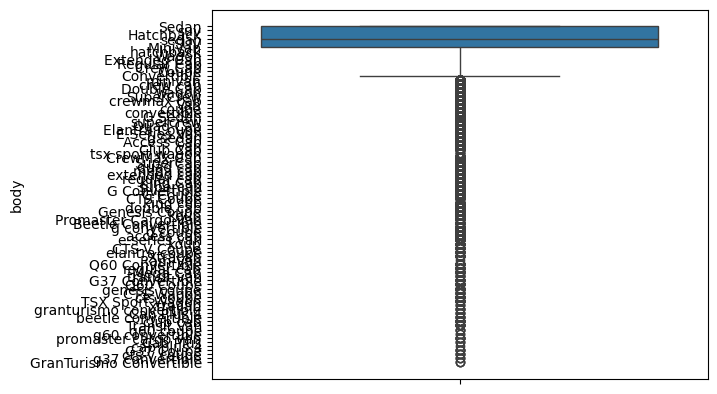

transmission


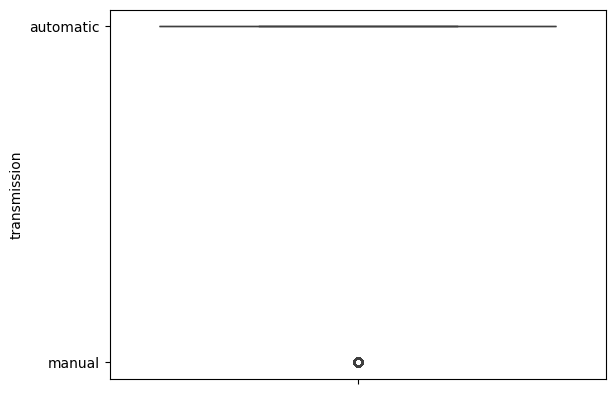

state


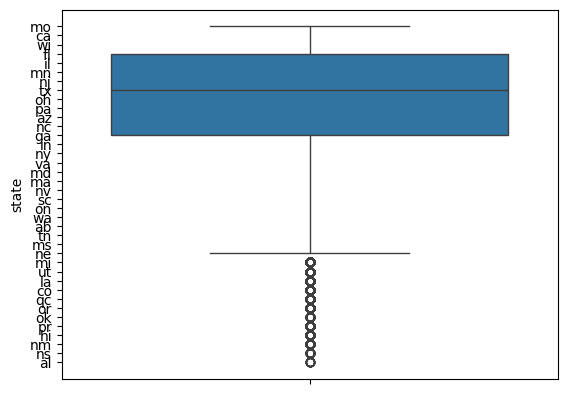

condition


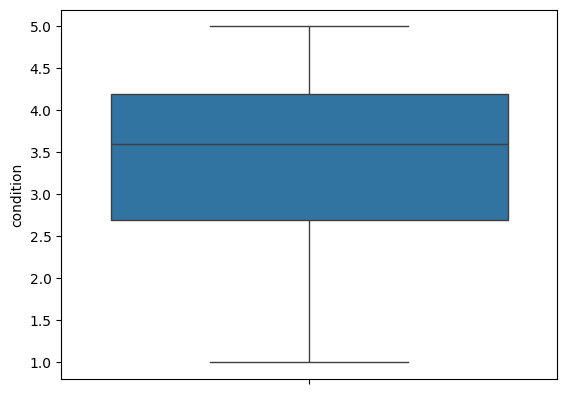

odometer


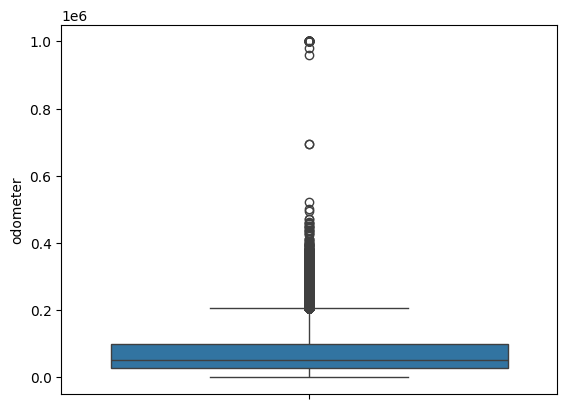

color


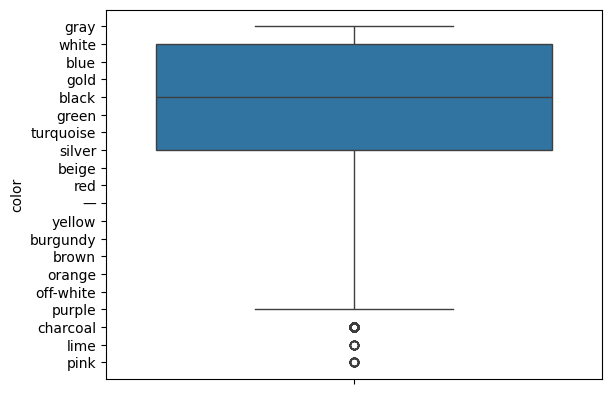

interior


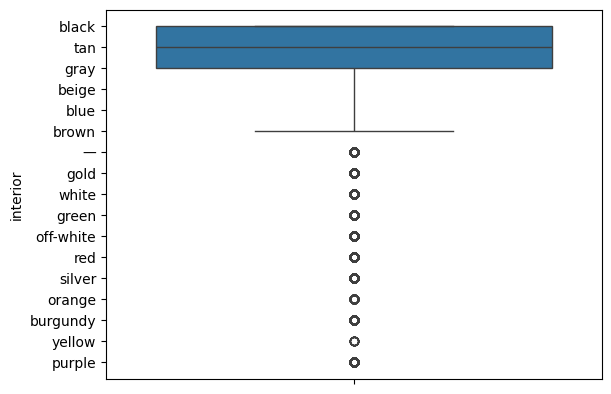

seller


KeyboardInterrupt: 

In [21]:
for col in num_cols:
    print(col)
    sb.boxplot(X[col])
    plt.show()

In [ ]:
X[X['odometer'] > 800000][['car_age','odometer']]

Выкинем машины младше 10 лет, проехавшие 1_000_000 миль - это почти точно выбросы.

In [17]:
Xnew = X[~((X.car_age < 10) & (X.odometer > 800_000))]
ynew = y[~((X.car_age < 10) & (X.odometer > 800_000))]

Xnew.drop('car_age', axis=1, inplace=True)

/tmp/ipykernel_1149/4066289098.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Xnew.drop('car_age', axis=1, inplace=True)


## Построение baseline

Для baseline-модели мы сделаем следующее:
* закодируем категориальные признаки при помощи TargetEncoder
* масштабируем все признаки с помощью StandardScaler
* обучим линейную регрессию

In [18]:
!pip install category_encoders -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 4.9 MB/s eta 0:00:00


In [19]:
from category_encoders.ordinal import OrdinalEncoder
from category_encoders.one_hot import OneHotEncoder
from category_encoders.target_encoder import TargetEncoder
from category_encoders.leave_one_out import LeaveOneOutEncoder

Разобъем данные на тренировочную и тестовую части

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(Xnew, ynew, test_size=0.25, random_state=42)

Осуществим задуманные шаги

In [23]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler


enc = TargetEncoder(cols=cat_cols)
enc.fit(X_train, y_train)
X_train_new = enc.transform(X_train)
X_test_new = enc.transform(X_test)

scaler = StandardScaler()
scaler.fit(X_train_new)
X_train_new = pd.DataFrame(scaler.transform(X_train_new), columns=X_train.columns)
X_test_new = pd.DataFrame(scaler.transform(X_test_new), columns=X_test.columns)

model = LinearRegression()
model.fit(X_train_new, y_train)
pred = model.predict(X_test_new)

Оценим качество полученной модели

In [24]:
from sklearn.metrics import mean_absolute_percentage_error as MAPE

MAPE(y_test, pred)

0.7151865211267131

Ошибка в среднем 71% от цены - модель пока не очень хорошая, есть куда улучшать!

## Pipeline

In [ ]:
from sklearn.pipeline import Pipeline

p1 = Pipeline([
    ('encoder_',TargetEncoder(cols=cat_cols)),
    ('scaler_', StandardScaler()),
    ('model_', LinearRegression())
    ])

In [ ]:
p1.fit(X_train, y_train)

Pipeline(steps=[('encoder_',
                 TargetEncoder(cols=Index(['model', 'trim', 'body', 'transmission', 'state', 'color', 'interior',
       'seller', 'date'],
      dtype='object'))),
                ('scaler_', StandardScaler()), ('model_', LinearRegression())])

In [ ]:
pred = p1.predict(X_test)

MAPE(y_test, pred)

0.7151865211267128

In [3]:
import sklearn; print(sklearn.__version__)
import category_encoders as ce; print(ce.__version__)  # если используете
import pandas as pd; print(pd.__version__)
import numpy as np; print(np.__version__)

1.6.1
2.8.1
2.2.2
2.0.2


In [4]:
import sys
print(sys.version)


3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]


In [13]:
import scikit-learn as np; print(np.__version__)

SyntaxError: invalid syntax (1514750093.py, line 1)

In [14]:
pithon --version scikit-learn

SyntaxError: invalid syntax (1750782723.py, line 1)

In [2]:
pip!pip install category_encoders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 6.5 MB/s eta 0:00:00
